<a id="6"></a>
<h2 style="background-color: #3498db; font-size: 20px; color: #ffffff; text-align: center; font-family: 'Indie Flower', cursive; font-weight: bold; margin: 10px; border: 2px solid #2980b9; border-radius: 12px; padding: 15px;">Step 1. Imports</h2>


*   Import modules
*   Load dataframe



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt 
import warnings 
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

In [2]:
df = pd.read_csv(r'D:\CSV_Files\CarPrice_Assignment.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')


## <p style="background-color: #e67e22; font-size: 20px; color: #ffffff; text-align: center; font-family: 'Zilla Slab', serif; font-weight: bold; margin: 15px; border: 3px solid #d35400; border-radius: 15px; padding: 20px;">Step 2. Data Cleaning</p>

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers, consistency) 



In [4]:
df['cylindernumber']

0      four
1      four
2       six
3      four
4      five
       ... 
200    four
201    four
202     six
203     six
204    four
Name: cylindernumber, Length: 205, dtype: object

# *1.Renaming Columns with More Suitable Names*

In [5]:
df.rename(columns={'symboling':'risk_rating'},inplace=True)

In [6]:
df.columns

Index(['car_ID', 'risk_rating', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

## *Getting Some Information*

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   risk_rating       205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [8]:
df['doornumber'].value_counts()

doornumber
four    115
two      90
Name: count, dtype: int64

# *Check of concistency*

In [9]:
Categorical_columns = df.select_dtypes(include='object')
for col in Categorical_columns:
    print(f'Column {col} has Unique Values:')
    print(df[col].unique())
    print('--------------------------------')

Column CarName has Unique Values:
['alfa-romero giulia' 'alfa-romero stelvio' 'alfa-romero Quadrifoglio'
 'audi 100 ls' 'audi 100ls' 'audi fox' 'audi 5000' 'audi 4000'
 'audi 5000s (diesel)' 'bmw 320i' 'bmw x1' 'bmw x3' 'bmw z4' 'bmw x4'
 'bmw x5' 'chevrolet impala' 'chevrolet monte carlo' 'chevrolet vega 2300'
 'dodge rampage' 'dodge challenger se' 'dodge d200' 'dodge monaco (sw)'
 'dodge colt hardtop' 'dodge colt (sw)' 'dodge coronet custom'
 'dodge dart custom' 'dodge coronet custom (sw)' 'honda civic'
 'honda civic cvcc' 'honda accord cvcc' 'honda accord lx'
 'honda civic 1500 gl' 'honda accord' 'honda civic 1300' 'honda prelude'
 'honda civic (auto)' 'isuzu MU-X' 'isuzu D-Max ' 'isuzu D-Max V-Cross'
 'jaguar xj' 'jaguar xf' 'jaguar xk' 'maxda rx3' 'maxda glc deluxe'
 'mazda rx2 coupe' 'mazda rx-4' 'mazda glc deluxe' 'mazda 626' 'mazda glc'
 'mazda rx-7 gs' 'mazda glc 4' 'mazda glc custom l' 'mazda glc custom'
 'buick electra 225 custom' 'buick century luxus (sw)' 'buick century'
 

## *Lower for all columns*

In [10]:
# from above info we can conclude that cylindernumber,doornumber must be encoded at the end 
# column Carname has alot of unique values as seen :)

In [11]:
df.columns=df.columns.str.lower()
df.columns

Index(['car_id', 'risk_rating', 'carname', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

## *Check for all Duplication*

In [12]:
df.duplicated().sum()

0

In [13]:
df.isnull().sum()

car_id              0
risk_rating         0
carname             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [14]:
df.describe()

,car_id,risk_rating,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


from above describtion we can conclude that enginesize right skewed - horse power are left skewed - price are right skewed

In [15]:
df.drop('car_id',inplace=True,axis=1)

In [16]:
df.columns

Index(['risk_rating', 'carname', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

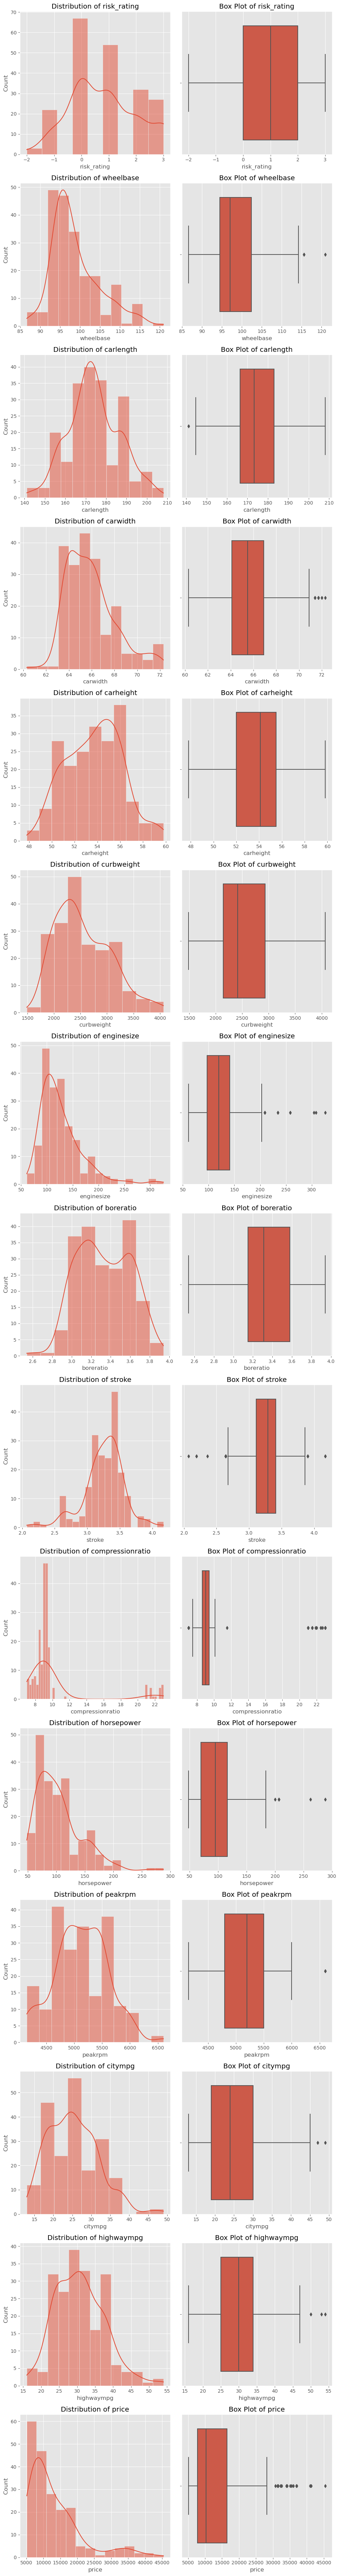

In [17]:
# Plotting
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numerical_columns)

plt.figure(figsize=(10, 5 * n_cols))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(n_cols, 2, 2*i-1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    plt.subplot(n_cols, 2, 2*i)
    sns.boxplot(x=df[col], orient='h')
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

In [18]:
def is_outlier(col,df):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    s=0
    for item in df.loc[:,col].to_list():
        if (item > Q3) or (item <Q1):
            s+=1
    return s/len(col) , s
for col in numerical_columns:
    print(f'Column {col} has percentage of outliers = {is_outlier(col,df)[0]}%, with count = {is_outlier(col,df)[1]} of {df.shape[0]}')
    print('----------------------------------------')

Column risk_rating has percentage of outliers = 4.7272727272727275%, with count = 52 of 205
----------------------------------------
Column wheelbase has percentage of outliers = 9.444444444444445%, with count = 85 of 205
----------------------------------------
Column carlength has percentage of outliers = 10.666666666666666%, with count = 96 of 205
----------------------------------------
Column carwidth has percentage of outliers = 12.25%, with count = 98 of 205
----------------------------------------
Column carheight has percentage of outliers = 11.0%, with count = 99 of 205
----------------------------------------
Column curbweight has percentage of outliers = 10.1%, with count = 101 of 205
----------------------------------------
Column enginesize has percentage of outliers = 8.9%, with count = 89 of 205
----------------------------------------
Column boreratio has percentage of outliers = 11.11111111111111%, with count = 100 of 205
----------------------------------------
Colum

<a id="10"></a>
<h1 style="background-color: #3498db; font-size: 20px; color: #ecf0f1; text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: bold; margin: 10px; border: 1px solid; border-color: #2980b9; border-radius: 8px; padding: 15px;">Step 2. Data Exploration (Continue EDA)</h1>


Begin by understanding how many employees left and what percentage of all employees this figure represents.

## *1.UnderStanding of how each feature affect on Target Feature*

In [19]:
df.head()

,risk_rating,carname,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [20]:
numerical_columns = df.select_dtypes(include = np.number).columns
categorical_columns = df.select_dtypes(include = 'object').columns
numerical_columns

Index(['risk_rating', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [21]:
categorical_columns

Index(['carname', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')

<Axes: xlabel='price', ylabel='Density'>

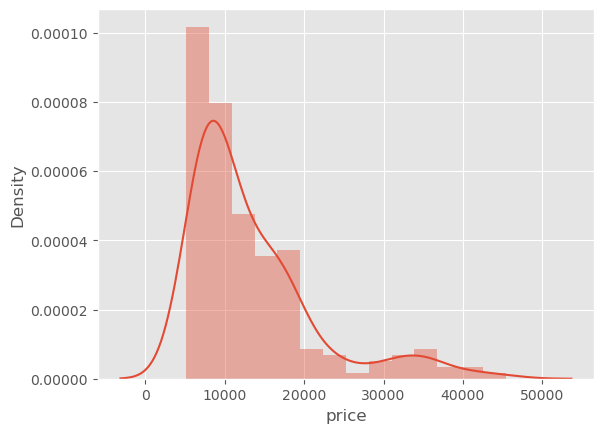

In [22]:
sns.distplot(df['price'])

In [23]:
df['price'].skew()

1.7776781560914454

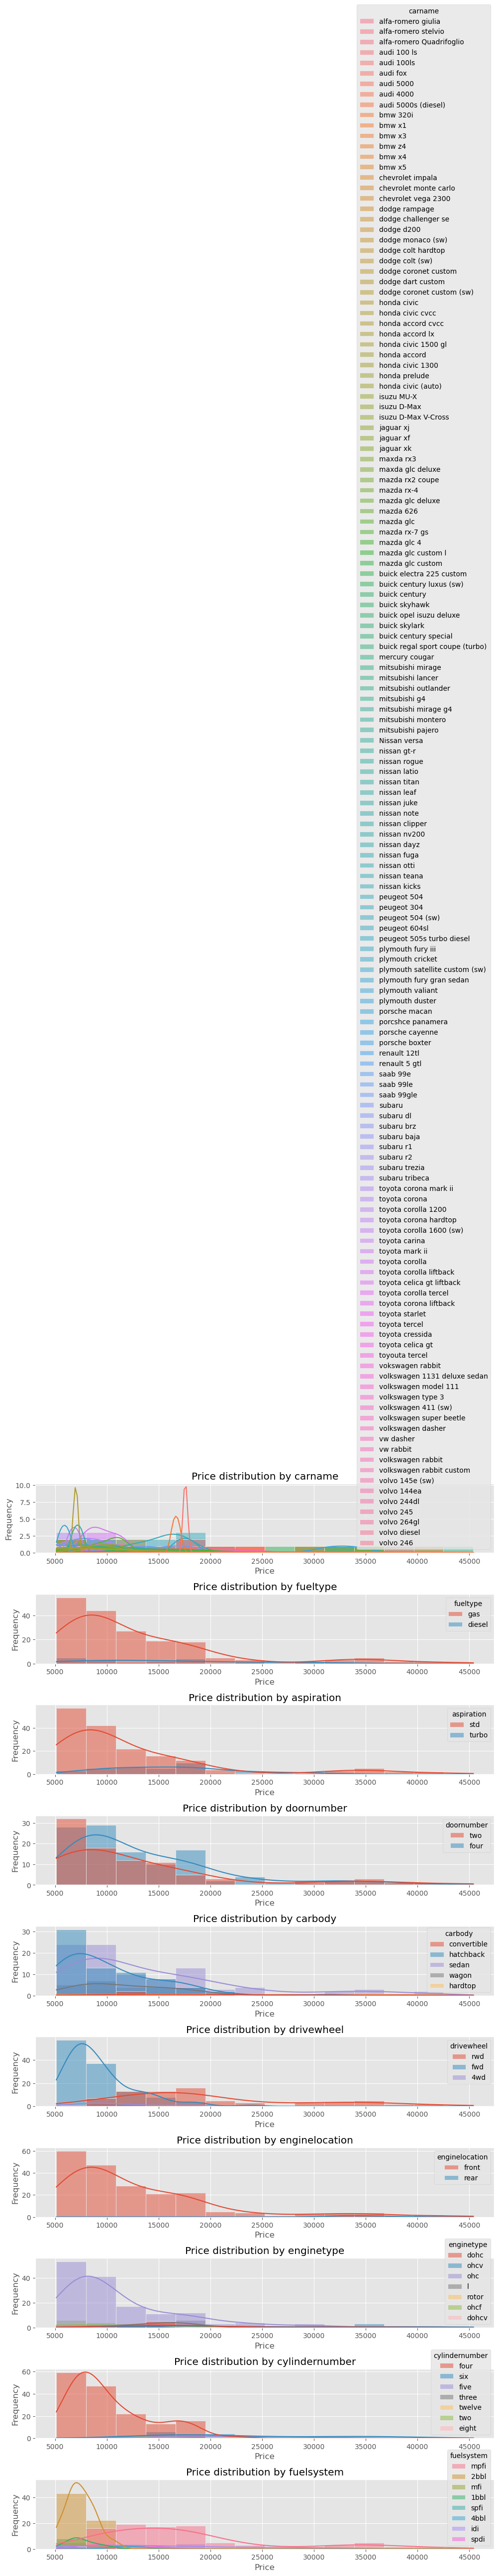

In [24]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5 * len(categorical_columns)))

# Loop through each categorical column and create a histplot
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(len(categorical_columns), 1, i)
    sns.histplot(data=df, x='price', hue=col, kde=True)
    plt.title(f'Price distribution by {col}')
    plt.xlabel('Price')
    plt.ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()


In [25]:
df.drop(['carbody','doornumber','carname'],axis=1,inplace=True)

In [26]:
df.columns

Index(['risk_rating', 'fueltype', 'aspiration', 'drivewheel', 'enginelocation',
       'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio',
       'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg',
       'highwaympg', 'price'],
      dtype='object')

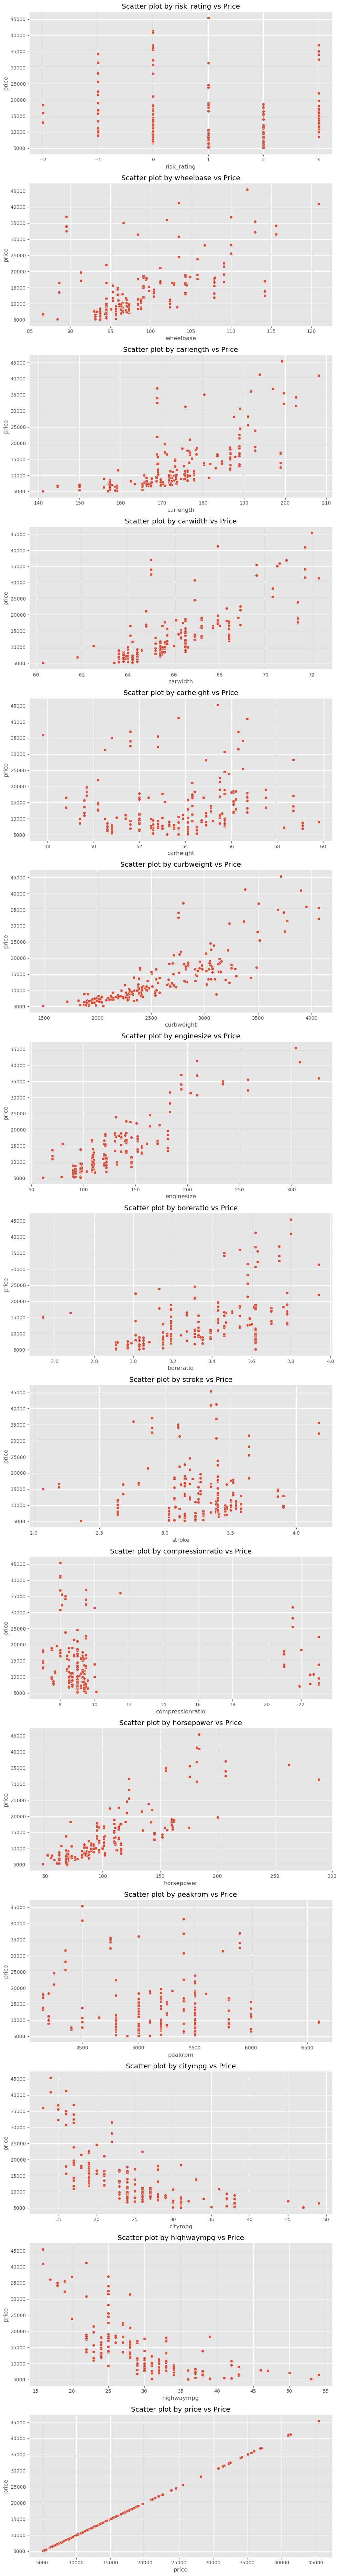

In [27]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5 * len(numerical_columns)))

# Loop through each categorical column and create a histplot
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, i)
    sns.scatterplot(data=df, x=col, y='price')
    plt.title(f'Scatter plot by {col} vs Price')
    plt.xlabel(f'{col}')
    plt.ylabel('price')

# Adjust layout
plt.tight_layout()
plt.show()


In [28]:
df.drop(df [(df['risk_rating']==3) & (df['price']>30000)].index , axis=0 ,inplace=True)

In [29]:
df.drop(df [(df['risk_rating']==1) & (df['price']>45000)].index , axis=0 ,inplace=True)

In [30]:
df.drop(df[(df['carheight']<48) & (df['price']>35000)].index , axis=0 ,inplace=True)

In [31]:
df.drop(df[(df['boreratio']<2.8) ].index, axis=0 ,inplace=True)

In [32]:
df.drop(df[(df['stroke']<2.8) ].index, axis=0 ,inplace=True)

In [33]:
df.drop(df[(df['horsepower']<2.8) ].index, axis=0 ,inplace=True)

In [34]:
df.drop(df[(df['peakrpm']>6500) ].index, axis=0 ,inplace=True)

In [35]:
df.drop(df[(df['citympg']>40) ].index, axis=0 ,inplace=True)

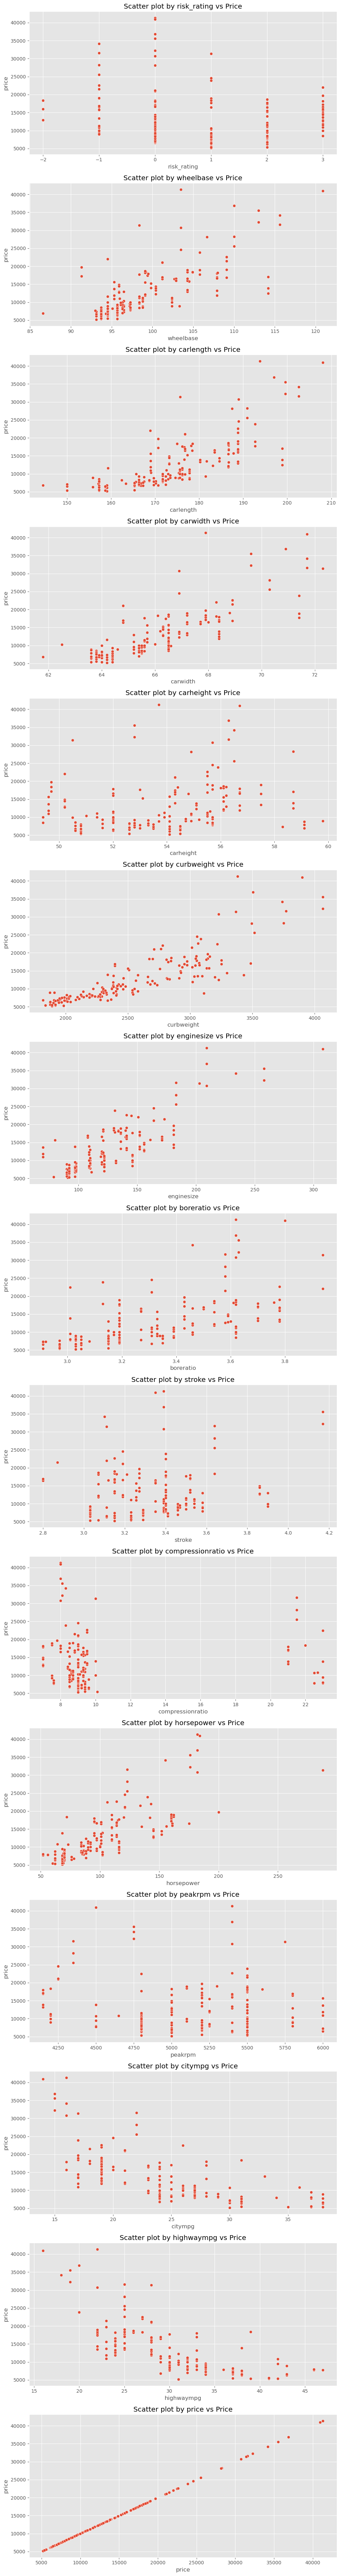

In [36]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5 * len(numerical_columns)))

# Loop through each categorical column and create a histplot
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, i)
    sns.scatterplot(data=df, x=col, y='price')
    plt.title(f'Scatter plot by {col} vs Price')
    plt.xlabel(f'{col}')
    plt.ylabel('price')

# Adjust layout
plt.tight_layout()
plt.show()


In [37]:
df.drop(df[(df['citympg']>45) ].index, axis=0 ,inplace=True)
df.drop(df[(df['horsepower']>200) ].index, axis=0 ,inplace=True)
df.drop(df[(df['stroke']>4) ].index, axis=0 ,inplace=True)
df.drop(df[(df['boreratio']>3.8) ].index, axis=0 ,inplace=True)
df.drop(df[(df['enginesize']>300) ].index, axis=0 ,inplace=True)

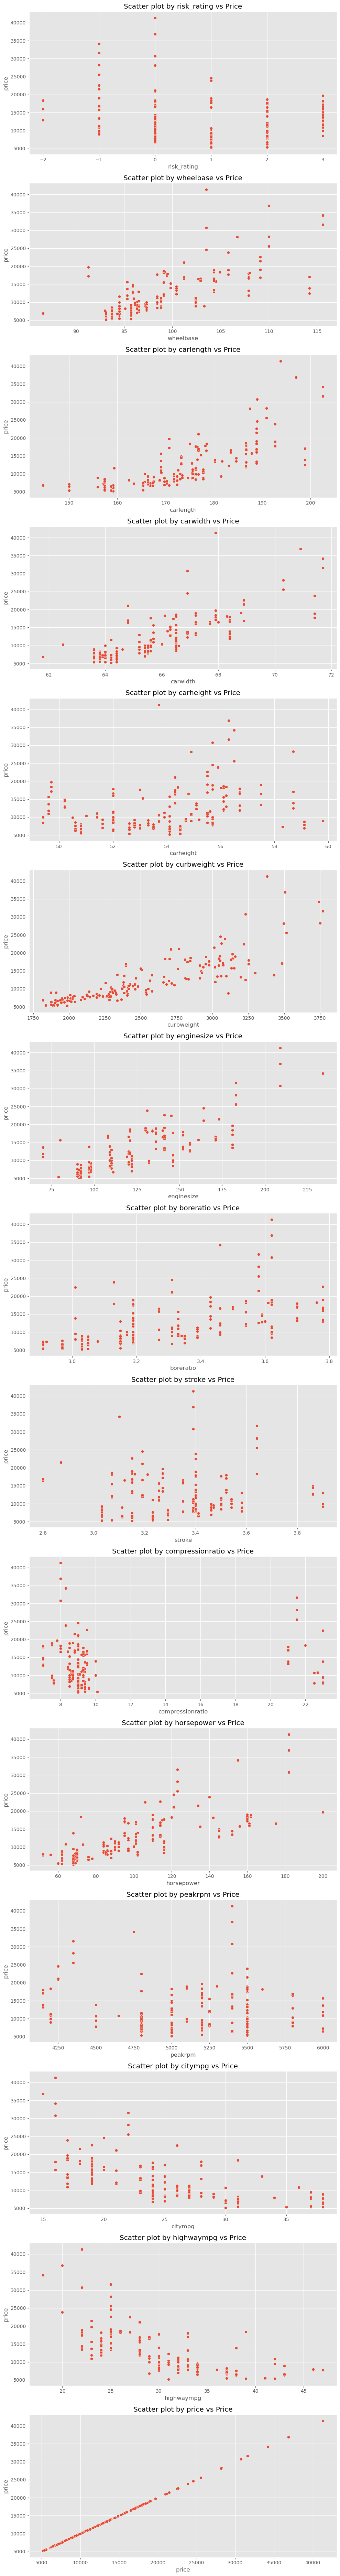

In [38]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5 * len(numerical_columns)))

# Loop through each categorical column and create a histplot
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, i)
    sns.scatterplot(data=df, x=col, y='price')
    plt.title(f'Scatter plot by {col} vs Price')
    plt.xlabel(f'{col}')
    plt.ylabel('price')

# Adjust layout
plt.tight_layout()
plt.show()


In [39]:
df[numerical_columns].corr()['price']

risk_rating        -0.226613
wheelbase           0.720871
carlength           0.757529
carwidth            0.789339
carheight           0.299250
curbweight          0.842642
enginesize          0.805196
boreratio           0.593310
stroke              0.095801
compressionratio    0.163359
horsepower          0.740910
peakrpm            -0.157810
citympg            -0.668817
highwaympg         -0.700736
price               1.000000
Name: price, dtype: float64

In [40]:
df.drop(['stroke','compressionratio','peakrpm'],axis=1,inplace=True)

In [41]:
df[df.select_dtypes(include=np.number).columns].corr()['price']

risk_rating   -0.226613
wheelbase      0.720871
carlength      0.757529
carwidth       0.789339
carheight      0.299250
curbweight     0.842642
enginesize     0.805196
boreratio      0.593310
horsepower     0.740910
citympg       -0.668817
highwaympg    -0.700736
price          1.000000
Name: price, dtype: float64

In [42]:
df.isnull().sum()

risk_rating       0
fueltype          0
aspiration        0
drivewheel        0
enginelocation    0
wheelbase         0
carlength         0
carwidth          0
carheight         0
curbweight        0
enginetype        0
cylindernumber    0
enginesize        0
fuelsystem        0
boreratio         0
horsepower        0
citympg           0
highwaympg        0
price             0
dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 171 entries, 3 to 204
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   risk_rating     171 non-null    int64  
 1   fueltype        171 non-null    object 
 2   aspiration      171 non-null    object 
 3   drivewheel      171 non-null    object 
 4   enginelocation  171 non-null    object 
 5   wheelbase       171 non-null    float64
 6   carlength       171 non-null    float64
 7   carwidth        171 non-null    float64
 8   carheight       171 non-null    float64
 9   curbweight      171 non-null    int64  
 10  enginetype      171 non-null    object 
 11  cylindernumber  171 non-null    object 
 12  enginesize      171 non-null    int64  
 13  fuelsystem      171 non-null    object 
 14  boreratio       171 non-null    float64
 15  horsepower      171 non-null    int64  
 16  citympg         171 non-null    int64  
 17  highwaympg      171 non-null    int64  


In [44]:
numerical_columns = df.select_dtypes(include = np.number ).columns
categorical_columns = df.select_dtypes(include = 'object').columns
categorical_columns

Index(['fueltype', 'aspiration', 'drivewheel', 'enginelocation', 'enginetype',
       'cylindernumber', 'fuelsystem'],
      dtype='object')

In [45]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
new_df= encoder.fit_transform(df[categorical_columns])
new_df

array([[1., 0., 1., ..., 2., 2., 5.],
       [1., 0., 0., ..., 2., 1., 5.],
       [1., 0., 1., ..., 2., 1., 5.],
       ...,
       [1., 0., 2., ..., 3., 3., 5.],
       [0., 1., 2., ..., 2., 3., 3.],
       [1., 1., 2., ..., 2., 2., 5.]])

In [46]:
new_df = pd.DataFrame(new_df,columns=categorical_columns)

In [47]:
new_df

,fueltype,aspiration,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,1.0,0.0,1.0,0.0,2.0,2.0,5.0
1,1.0,0.0,0.0,0.0,2.0,1.0,5.0
2,1.0,0.0,1.0,0.0,2.0,1.0,5.0
3,1.0,0.0,1.0,0.0,2.0,1.0,5.0
4,1.0,0.0,1.0,0.0,2.0,1.0,5.0
...,...,...,...,...,...,...,...
166,1.0,0.0,2.0,0.0,2.0,2.0,5.0
167,1.0,1.0,2.0,0.0,2.0,2.0,5.0
168,1.0,0.0,2.0,0.0,3.0,3.0,5.0
169,0.0,1.0,2.0,0.0,2.0,3.0,3.0


In [48]:
new_df['price'] = df['price']

In [49]:
new_df

,fueltype,aspiration,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem,price
0,1.0,0.0,1.0,0.0,2.0,2.0,5.0,NaN
1,1.0,0.0,0.0,0.0,2.0,1.0,5.0,NaN
2,1.0,0.0,1.0,0.0,2.0,1.0,5.0,NaN
3,1.0,0.0,1.0,0.0,2.0,1.0,5.0,13950.0
4,1.0,0.0,1.0,0.0,2.0,1.0,5.0,17450.0
...,...,...,...,...,...,...,...,...
166,1.0,0.0,2.0,0.0,2.0,2.0,5.0,NaN
167,1.0,1.0,2.0,0.0,2.0,2.0,5.0,8449.0
168,1.0,0.0,2.0,0.0,3.0,3.0,5.0,9639.0
169,0.0,1.0,2.0,0.0,2.0,3.0,3.0,9989.0


In [50]:
new_df['price'].isnull().sum()

34

In [51]:
for col in new_df.columns:
    print(f" {col} has corr with Target = {new_df[col].corr(df['price'])}")
    print('---------------------')


 fueltype has corr with Target = 0.12539673762593084
---------------------
 aspiration has corr with Target = 0.05143129922744985
---------------------
 drivewheel has corr with Target = 0.021259728245659693
---------------------
 enginelocation has corr with Target = nan
---------------------
 enginetype has corr with Target = -0.12321884071103087
---------------------
 cylindernumber has corr with Target = 0.005285425584455344
---------------------
 fuelsystem has corr with Target = 0.14366630029986446
---------------------
 price has corr with Target = 1.0
---------------------


In [52]:
def calculate_correlations(new_df, target_col):
    correlations = {}
    
    for col in new_df.columns:
        corr_value = new_df[col].corr(df[target_col])
        correlations[col] = corr_value
        print(f" {col} has corr with Target = {corr_value}")
        print('---------------------')
    
    return correlations

# Usage
correlations = calculate_correlations(new_df, 'price')


 fueltype has corr with Target = 0.12539673762593084
---------------------
 aspiration has corr with Target = 0.05143129922744985
---------------------
 drivewheel has corr with Target = 0.021259728245659693
---------------------
 enginelocation has corr with Target = nan
---------------------
 enginetype has corr with Target = -0.12321884071103087
---------------------
 cylindernumber has corr with Target = 0.005285425584455344
---------------------
 fuelsystem has corr with Target = 0.14366630029986446
---------------------
 price has corr with Target = 1.0
---------------------


In [53]:
df.drop(['aspiration','cylindernumber','enginelocation','enginetype'],axis=1,inplace=True)

In [54]:
df.head()

,risk_rating,fueltype,drivewheel,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,fuelsystem,boreratio,horsepower,citympg,highwaympg,price
3,2,gas,fwd,99.8,176.6,66.2,54.3,2337,109,mpfi,3.19,102,24,30,13950.0
4,2,gas,4wd,99.4,176.6,66.4,54.3,2824,136,mpfi,3.19,115,18,22,17450.0
5,2,gas,fwd,99.8,177.3,66.3,53.1,2507,136,mpfi,3.19,110,19,25,15250.0
6,1,gas,fwd,105.8,192.7,71.4,55.7,2844,136,mpfi,3.19,110,19,25,17710.0
7,1,gas,fwd,105.8,192.7,71.4,55.7,2954,136,mpfi,3.19,110,19,25,18920.0


In [55]:
df['risk_rating'].value_counts()

risk_rating
 0    52
 1    48
 2    27
-1    22
 3    19
-2     3
Name: count, dtype: int64

Text(0, 0.5, 'risk_rating')

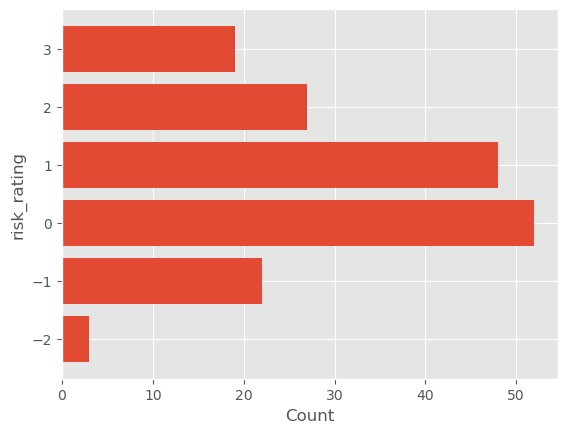

In [56]:
plt.barh(df['risk_rating'].value_counts().index,df['risk_rating'].value_counts().values)
plt.xlabel('Count')
plt.ylabel('risk_rating')

([<matplotlib.patches.Wedge at 0x203c675d450>,
 [Text(-1.0336618906921569, 0.3762221361519225, 'gas'),
  Text(1.0336618994982714, -0.3762221119573192, 'diesel')],
 [Text(-0.5638155767411764, 0.205212074264685, '88.9%'),
  Text(0.5638155815445116, -0.20521206106762865, '11.1%')])

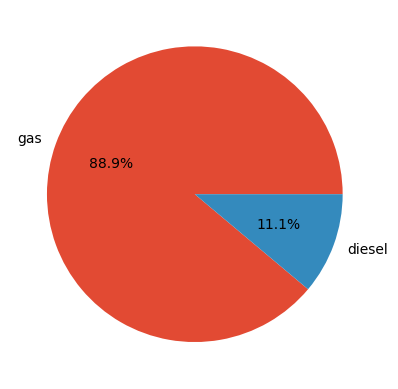

In [59]:
plt.pie(df['fueltype'].value_counts().values,labels=df['fueltype'].value_counts().index,autopct='%1.1f%%')

In [60]:
df['risk_rating'].dtype

dtype('int64')

In [61]:
df['price'].corr(df['risk_rating'])

-0.2266126437764183

<Axes: xlabel='price', ylabel='Count'>

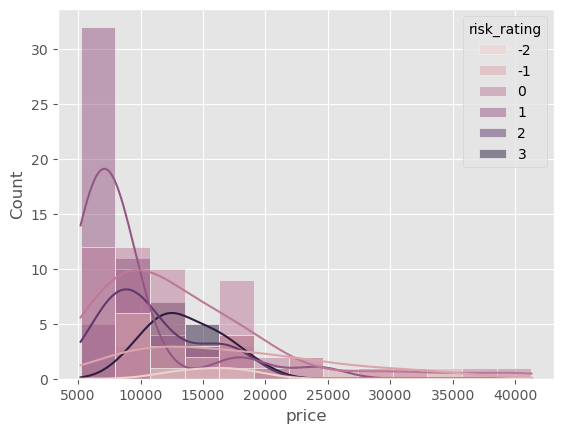

In [62]:
sns.histplot(data=df,x='price',hue='risk_rating',kde=True)

In [63]:
df['fueltype'].value_counts()

fueltype
gas       152
diesel     19
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x203c6c7a310>,
 [Text(-1.0336618906921569, 0.3762221361519225, 'gas'),
  Text(1.0336618994982714, -0.3762221119573192, 'diesel')],
 [Text(-0.5638155767411764, 0.205212074264685, '88.9%'),
  Text(0.5638155815445116, -0.20521206106762865, '11.1%')])

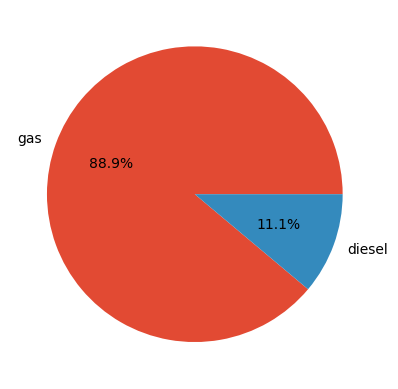

In [64]:
plt.pie(df['fueltype'].value_counts().values,labels=df['fueltype'].value_counts().index,autopct='%1.1f%%')

Text(0, 0.5, 'Count')

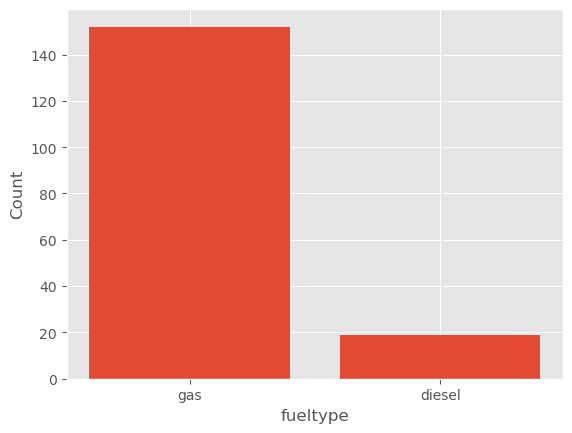

In [65]:
plt.bar(df['fueltype'].value_counts().index,df['fueltype'].value_counts().values)
plt.xlabel('fueltype')
plt.ylabel('Count')

<Axes: xlabel='price', ylabel='Count'>

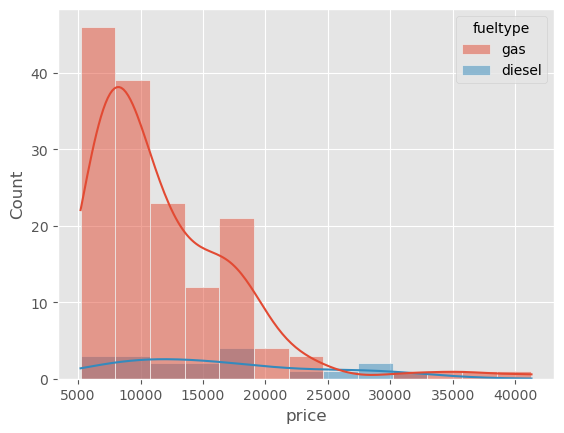

In [66]:
sns.histplot(data=df,x='price',hue='fueltype',kde=True)

<Axes: xlabel='price', ylabel='wheelbase'>

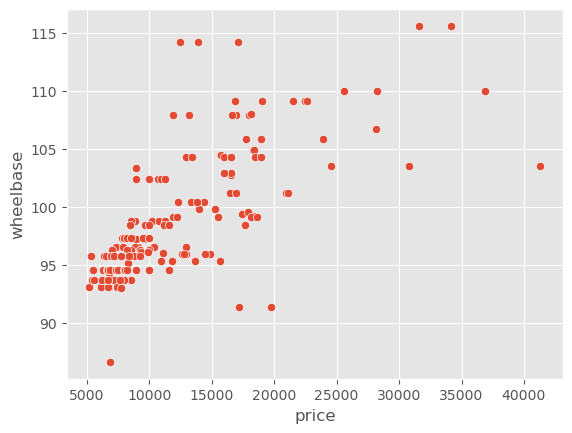

In [67]:
sns.scatterplot(data=df,x='price',y='wheelbase')

In [68]:
df['price'].corr(df['wheelbase'])

0.7208708792278684

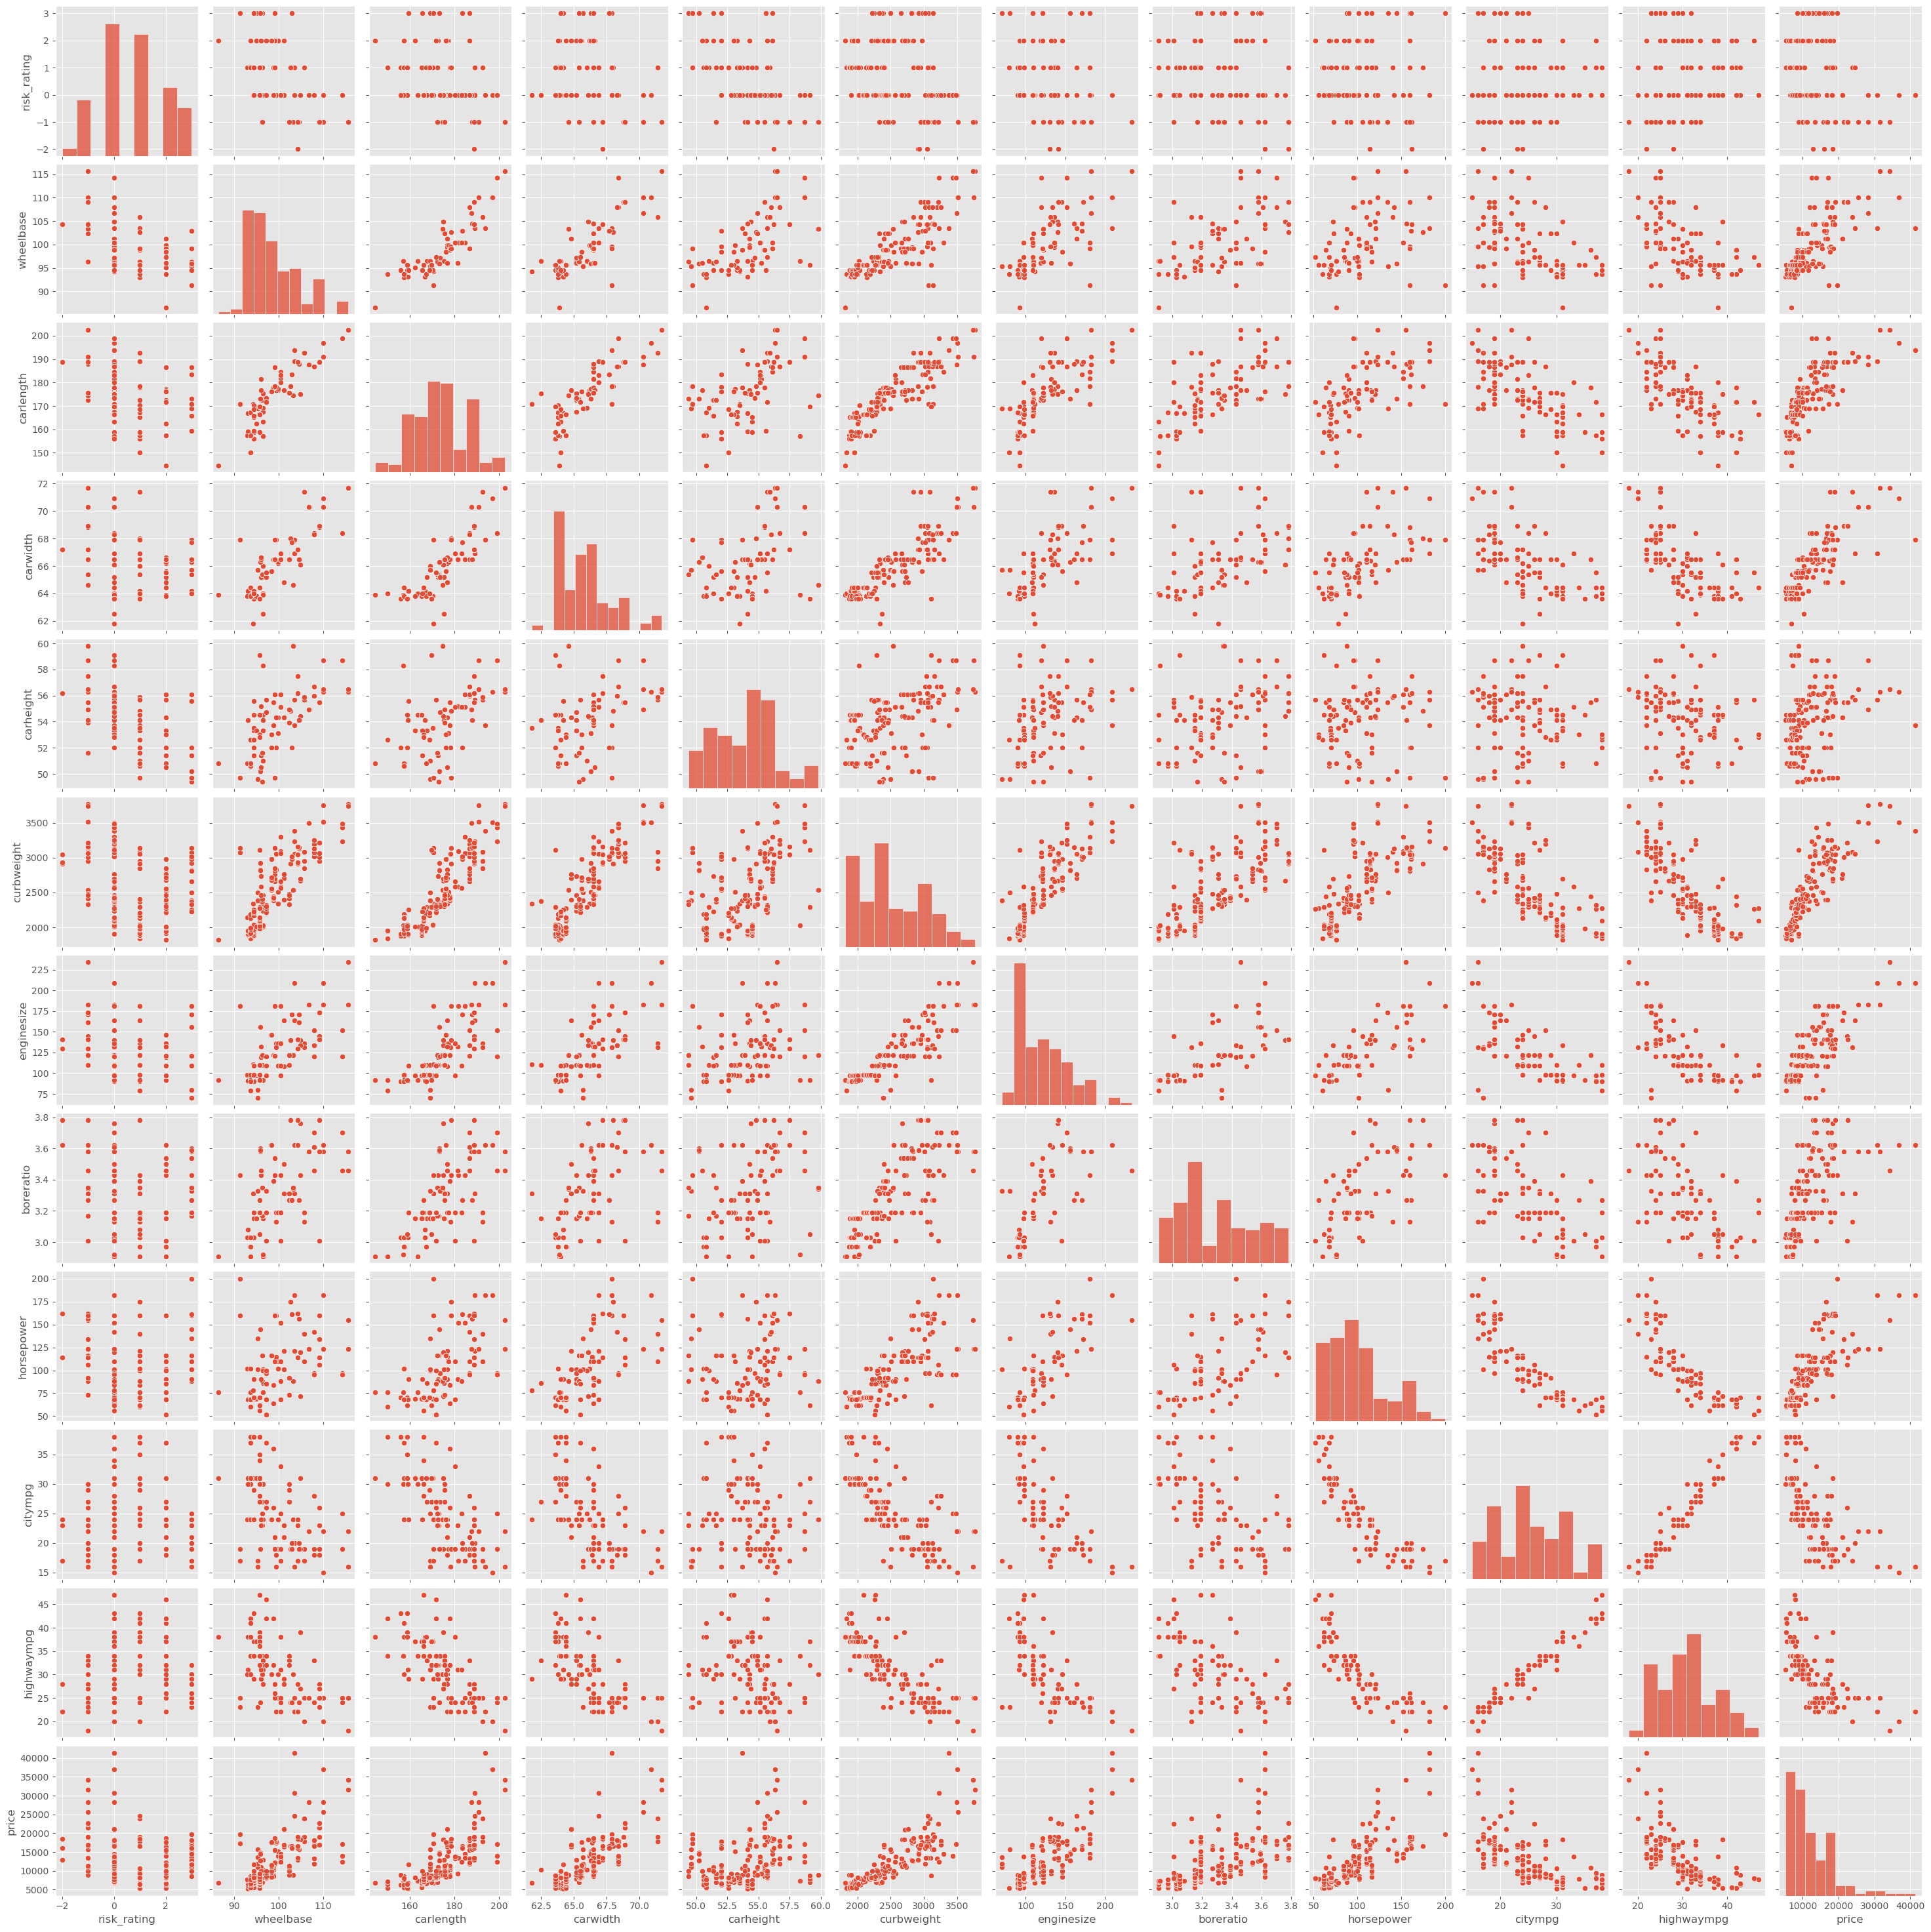

In [69]:
sns.pairplot(data=df)

In [70]:
df['carheight'].corr(df['price'])

0.29925025357269347

In [71]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include = 'object').columns
numerical_columns

Index(['risk_rating', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'horsepower', 'citympg',
       'highwaympg', 'price'],
      dtype='object')

<a id="10"></a>
<h1 style="background-color: #3498db; font-size: 20px; color: #ecf0f1; text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: bold; margin: 10px; border: 1px solid; border-color: #2980b9; border-radius: 8px; padding: 15px;">Step 2. Data Exploration (Continue EDA)</h1>


Begin by understanding how many employees left and what percentage of all employees this figure represents.

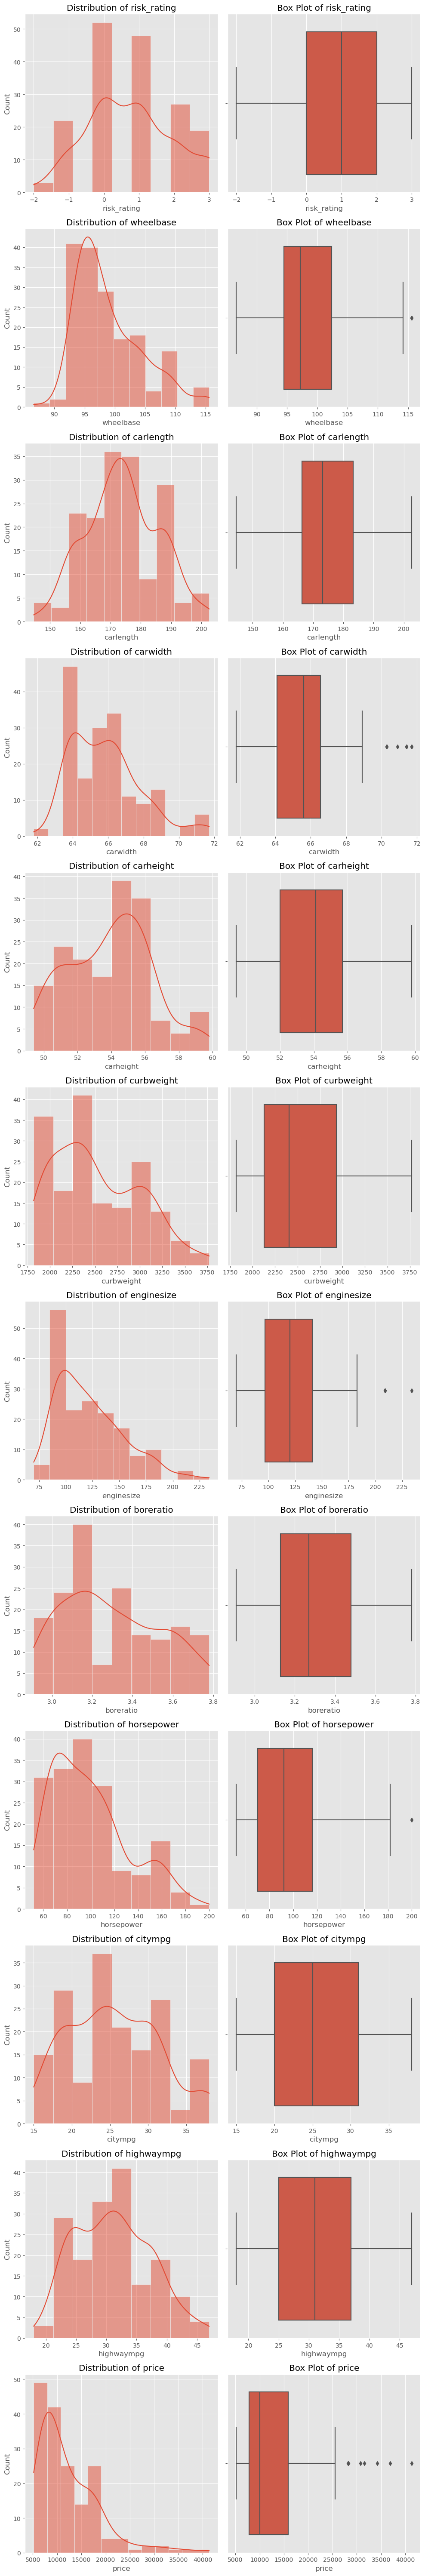

In [72]:
# Plotting
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numerical_columns)

plt.figure(figsize=(10, 5 * n_cols))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(n_cols, 2, 2*i-1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    plt.subplot(n_cols, 2, 2*i)
    sns.boxplot(x=df[col], orient='h')
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

In [73]:
df.drop(df[df['price']>30000].index,axis=0,inplace=True)

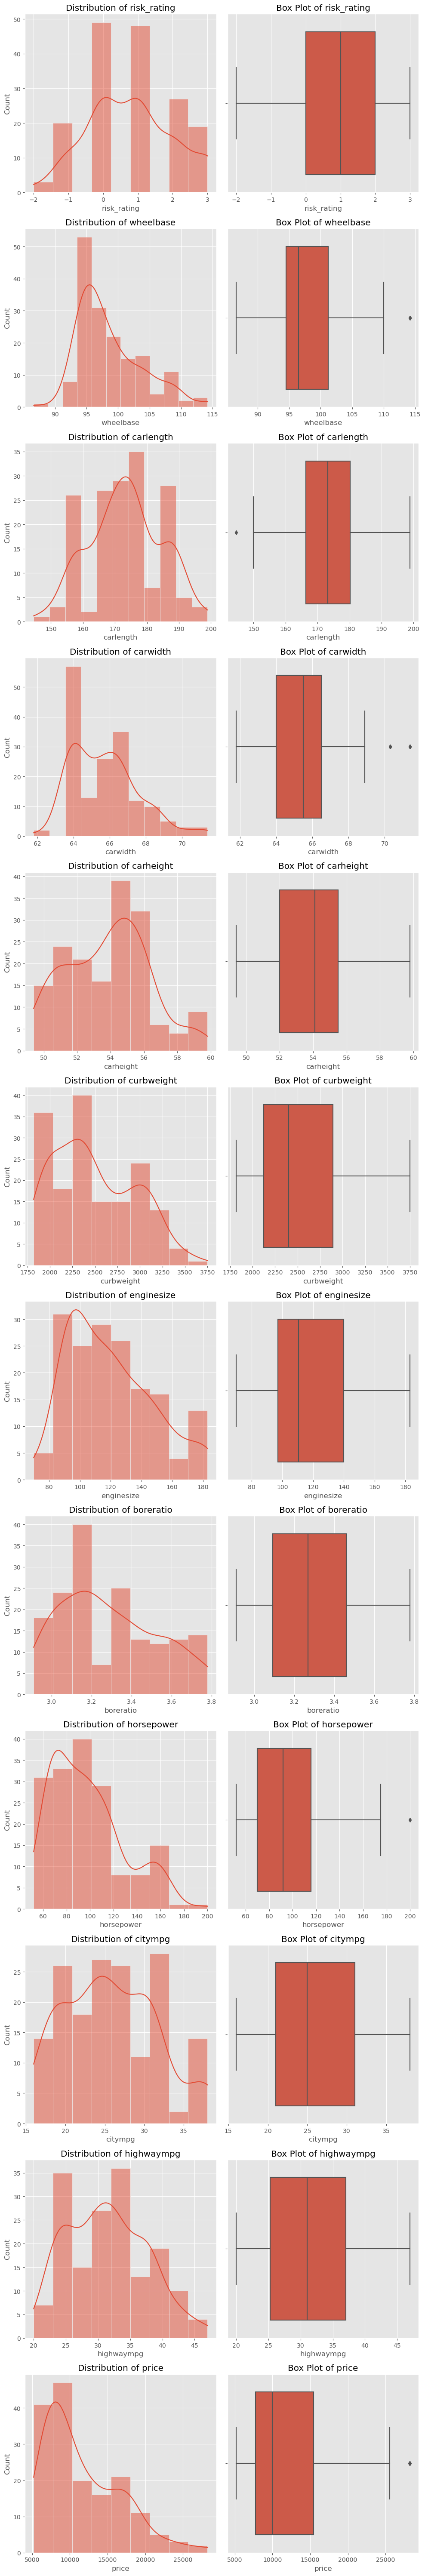

In [74]:
# Plotting
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numerical_columns)

plt.figure(figsize=(10, 5 * n_cols))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(n_cols, 2, 2*i-1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    plt.subplot(n_cols, 2, 2*i)
    sns.boxplot(x=df[col], orient='h')
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

In [75]:
for col in numerical_columns:
    print(f"column {col} has skeweness of {df[col].skew()}")
    print('-------------------------------------')

column risk_rating has skeweness of 0.13244050166179708
-------------------------------------
column wheelbase has skeweness of 0.9849710567365761
-------------------------------------
column carlength has skeweness of -0.0057845385913524415
-------------------------------------
column carwidth has skeweness of 0.8085007867913704
-------------------------------------
column carheight has skeweness of 0.13451970800062427
-------------------------------------
column curbweight has skeweness of 0.4553821656851037
-------------------------------------
column enginesize has skeweness of 0.641481084548994
-------------------------------------
column boreratio has skeweness of 0.39157155549330297
-------------------------------------
column horsepower has skeweness of 0.850580280883812
-------------------------------------
column citympg has skeweness of 0.3183724439357807
-------------------------------------
column highwaympg has skeweness of 0.33628036442527365
----------------------------

In [76]:
df.describe()

,risk_rating,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,horsepower,citympg,highwaympg,price
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,0.801205,98.629518,173.310843,65.722892,53.825904,2493.156627,119.506024,3.288735,97.801205,25.795181,31.457831,11631.916669
std,1.236907,5.123035,11.197900,1.843897,2.461385,452.241193,27.733963,0.243779,30.850022,5.821088,6.133467,5046.364606
min,-2.000000,86.600000,144.600000,61.800000,49.400000,1819.000000,70.000000,2.910000,52.000000,16.000000,20.000000,5195.000000
25%,0.000000,94.500000,166.300000,64.000000,52.000000,2123.500000,97.000000,3.092500,70.000000,21.000000,25.250000,7778.250000
50%,1.000000,96.500000,173.200000,65.500000,54.100000,2399.000000,110.500000,3.270000,92.000000,25.000000,31.000000,9984.000000
75%,2.000000,101.200000,180.200000,66.500000,55.500000,2894.250000,140.000000,3.460000,115.750000,31.000000,37.000000,15445.000000
max,3.000000,114.200000,198.900000,71.400000,59.800000,3750.000000,183.000000,3.780000,200.000000,38.000000,47.000000,28248.000000


In [77]:
for col in numerical_columns:
    if col == 'price':
        continue  # Use continue instead of break to skip 'price' but continue with other columns
    elif df[col].std() > 10:
        df[col] = df[col].apply(lambda x: (x - df[col].mean()) / df[col].std())
        
df.describe()


,risk_rating,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,horsepower,citympg,highwaympg,price
count,166.000000,166.000000,1.660000e+02,166.000000,166.000000,1.660000e+02,1.660000e+02,166.000000,1.660000e+02,166.000000,166.000000,166.000000
mean,0.801205,98.629518,-4.280378e-16,65.722892,53.825904,-1.498132e-16,-1.498132e-16,3.288735,1.819161e-16,25.795181,31.457831,11631.916669
std,1.236907,5.123035,1.000000e+00,1.843897,2.461385,1.000000e+00,1.000000e+00,0.243779,1.000000e+00,5.821088,6.133467,5046.364606
min,-2.000000,86.600000,-2.563949e+00,61.800000,49.400000,-1.490702e+00,-1.785032e+00,2.910000,-1.484641e+00,16.000000,20.000000,5195.000000
25%,0.000000,94.500000,-6.260855e-01,64.000000,52.000000,-8.173882e-01,-8.114969e-01,3.092500,-9.011729e-01,21.000000,25.250000,7778.250000
50%,1.000000,96.500000,-9.898585e-03,65.500000,54.100000,-2.082000e-01,-3.247291e-01,3.270000,-1.880454e-01,25.000000,31.000000,9984.000000
75%,2.000000,101.200000,6.152186e-01,66.500000,55.500000,8.869015e-01,7.389487e-01,3.460000,5.818082e-01,31.000000,37.000000,15445.000000
max,3.000000,114.200000,2.285175e+00,71.400000,59.800000,2.779144e+00,2.289394e+00,3.780000,3.312762e+00,38.000000,47.000000,28248.000000


<Axes: >

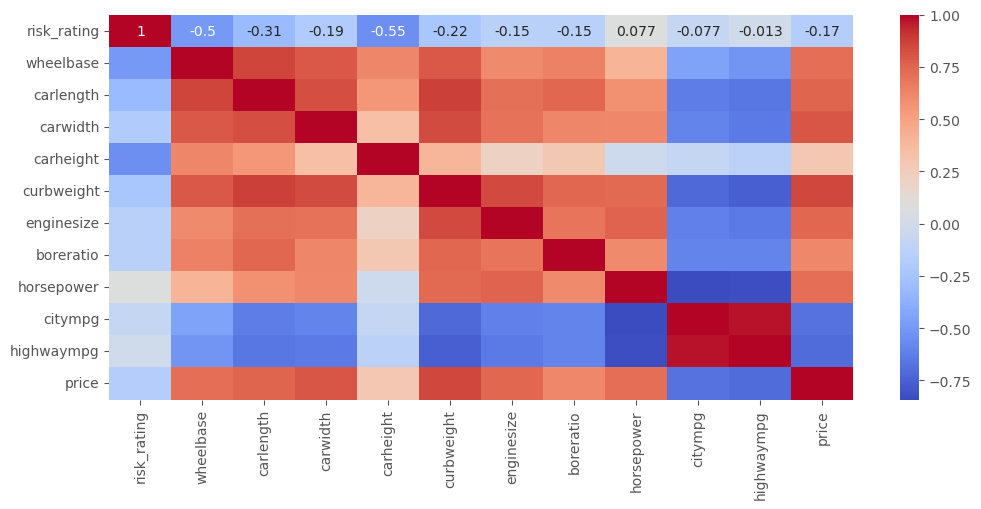

In [78]:
plt.figure(figsize=(12,5))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm', annot_kws={"size": 10})

In [79]:
df[numerical_columns].corr()['price']

risk_rating   -0.167376
wheelbase      0.716716
carlength      0.750272
carwidth       0.802355
carheight      0.291587
curbweight     0.855708
enginesize     0.743980
boreratio      0.613972
horsepower     0.718253
citympg       -0.678749
highwaympg    -0.710647
price          1.000000
Name: price, dtype: float64

In [80]:
for col in categorical_columns:
    print(df[col].value_counts())
    print('-----------------------')

fueltype
gas       148
diesel     18
Name: count, dtype: int64
-----------------------
drivewheel
fwd    109
rwd     53
4wd      4
Name: count, dtype: int64
-----------------------
fuelsystem
mpfi    67
2bbl    57
idi     18
1bbl    10
spdi     9
4bbl     3
mfi      1
spfi     1
Name: count, dtype: int64
-----------------------


In [81]:
new = pd.get_dummies(df[categorical_columns])
new.head()

,fueltype_diesel,fueltype_gas,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
3,False,True,False,True,False,False,False,False,False,False,True,False,False
4,False,True,True,False,False,False,False,False,False,False,True,False,False
5,False,True,False,True,False,False,False,False,False,False,True,False,False
6,False,True,False,True,False,False,False,False,False,False,True,False,False
7,False,True,False,True,False,False,False,False,False,False,True,False,False


In [82]:
new.replace({True:1,False:0},inplace=True)

In [83]:
new

,fueltype_diesel,fueltype_gas,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
3,0,1,0,1,0,0,0,0,0,0,1,0,0
4,0,1,1,0,0,0,0,0,0,0,1,0,0
5,0,1,0,1,0,0,0,0,0,0,1,0,0
6,0,1,0,1,0,0,0,0,0,0,1,0,0
7,0,1,0,1,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0,1,0,0,1,0,0,0,0,0,1,0,0
201,0,1,0,0,1,0,0,0,0,0,1,0,0
202,0,1,0,0,1,0,0,0,0,0,1,0,0
203,1,0,0,0,1,0,0,0,1,0,0,0,0


In [84]:
df.drop(categorical_columns,axis=1,inplace=True)

In [85]:
df.head()

,risk_rating,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,horsepower,citympg,highwaympg,price
3,2,99.8,0.293730,66.2,54.3,-0.345295,-0.378814,3.19,0.136103,24,30,13950.0
4,2,99.4,0.293730,66.4,54.3,0.731564,0.594721,3.19,0.557497,18,22,17450.0
5,2,99.8,0.356241,66.3,53.1,0.030611,0.594721,3.19,0.395423,19,25,15250.0
6,1,105.8,1.731499,71.4,55.7,0.775788,0.594721,3.19,0.395423,19,25,17710.0
7,1,105.8,1.731499,71.4,55.7,1.019021,0.594721,3.19,0.395423,19,25,18920.0


In [86]:
df = pd.concat([df,new],axis=1)
df.head()

,risk_rating,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,horsepower,citympg,...,drivewheel_fwd,drivewheel_rwd,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
3,2,99.8,0.293730,66.2,54.3,-0.345295,-0.378814,3.19,0.136103,24,...,1,0,0,0,0,0,0,1,0,0
4,2,99.4,0.293730,66.4,54.3,0.731564,0.594721,3.19,0.557497,18,...,0,0,0,0,0,0,0,1,0,0
5,2,99.8,0.356241,66.3,53.1,0.030611,0.594721,3.19,0.395423,19,...,1,0,0,0,0,0,0,1,0,0
6,1,105.8,1.731499,71.4,55.7,0.775788,0.594721,3.19,0.395423,19,...,1,0,0,0,0,0,0,1,0,0
7,1,105.8,1.731499,71.4,55.7,1.019021,0.594721,3.19,0.395423,19,...,1,0,0,0,0,0,0,1,0,0


In [87]:
df.corr()['price']

risk_rating       -0.167376
wheelbase          0.716716
carlength          0.750272
carwidth           0.802355
carheight          0.291587
curbweight         0.855708
enginesize         0.743980
boreratio          0.613972
horsepower         0.718253
citympg           -0.678749
highwaympg        -0.710647
price              1.000000
fueltype_diesel    0.264519
fueltype_gas      -0.264519
drivewheel_4wd     0.042613
drivewheel_fwd    -0.624418
drivewheel_rwd     0.621971
fuelsystem_1bbl   -0.199720
fuelsystem_2bbl   -0.590054
fuelsystem_4bbl    0.013835
fuelsystem_idi     0.264519
fuelsystem_mfi     0.020612
fuelsystem_mpfi    0.508794
fuelsystem_spdi   -0.030527
fuelsystem_spfi   -0.009035
Name: price, dtype: float64

In [88]:
df.drop(['drivewheel_4wd','fuelsystem_4bbl','fuelsystem_mfi','fuelsystem_spdi','fuelsystem_spfi'],axis=1,inplace=True)

In [89]:
df.head()

,risk_rating,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,horsepower,citympg,highwaympg,price,fueltype_diesel,fueltype_gas,drivewheel_fwd,drivewheel_rwd,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_idi,fuelsystem_mpfi
3,2,99.8,0.293730,66.2,54.3,-0.345295,-0.378814,3.19,0.136103,24,30,13950.0,0,1,1,0,0,0,0,1
4,2,99.4,0.293730,66.4,54.3,0.731564,0.594721,3.19,0.557497,18,22,17450.0,0,1,0,0,0,0,0,1
5,2,99.8,0.356241,66.3,53.1,0.030611,0.594721,3.19,0.395423,19,25,15250.0,0,1,1,0,0,0,0,1
6,1,105.8,1.731499,71.4,55.7,0.775788,0.594721,3.19,0.395423,19,25,17710.0,0,1,1,0,0,0,0,1
7,1,105.8,1.731499,71.4,55.7,1.019021,0.594721,3.19,0.395423,19,25,18920.0,0,1,1,0,0,0,0,1


<a id="10"></a>
<h1 style="background-color: #3498db; font-size: 20px; color: #ecf0f1; text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: bold; margin: 10px; border: 1px solid; border-color: #2980b9; border-radius: 8px; padding: 15px;">Step 3. Data Splitting </h1>


Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [90]:
from sklearn.model_selection import train_test_split
x = df.drop('price',axis=1)
y = df['price']
x_train, x_test, y_train, y_test = train_test_split(x, y,shuffle=True,random_state=42,test_size=0.2)

In [91]:
x_test.shape

(34, 19)

In [92]:
x_train.shape

(132, 19)

<a id="10"></a>
<h1 style="background-color: #3498db; font-size: 20px; color: #ecf0f1; text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: bold; margin: 10px; border: 1px solid; border-color: #2980b9; border-radius: 8px; padding: 15px;">Step 4. Modeling </h1>


Begin by understanding how many employees left and what percentage of all employees this figure represents.

## *Linear Regression*

In [94]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'positive': [True, False],
}
# fit intercept to adjust if there are any theta or not 
# positive restrict if the theta must be positive or not 

model = LinearRegression()

grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'copy_X': True, 'fit_intercept': True, 'positive': True}
Best Score: 0.7381016260801438


In [95]:
LR = LinearRegression()
LR.fit(x_train,y_train)

LinearRegression()

In [96]:
LR.score(x_test,y_test)

0.8460515846543909

In [97]:
LR.score(x_train,y_train)

0.8054055001361573

## *PolyRegression*

In [98]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
# Define a parameter grid
param_grid = {'polynomialfeatures__degree': [1, 2, 3, 4, 5, 6]}

# Create a pipeline with PolynomialFeatures and LinearRegression
pipeline = make_pipeline(PolynomialFeatures(), LinearRegression())

# Instantiate the GridSearchCV object
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the GridSearchCV object to your training data
grid_search.fit(x_train, y_train)

# Get the best parameter
best_degree = grid_search.best_params_['polynomialfeatures__degree']
print("Best polynomial degree:", best_degree)

Best polynomial degree: 1


In [99]:
poly_degree = 1
poly = PolynomialFeatures(degree=poly_degree)
x_poly = poly.fit_transform(x_train)

In [100]:
model = LinearRegression()
model.fit(x_poly, y_train)

LinearRegression()

In [101]:
x_test_poly=poly.fit_transform(x_test)

In [102]:
model.score(x_test_poly,y_test)

0.8460515846543908

# *RandomForest*

In [103]:
params = {
'n_estimators': [10, 25, 50, 100, 200], 
'max_depth': [3, 5, 10, 15, 20, 25, None], 
'min_samples_leaf': [1, 2, 5, 10]
}
from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(estimator=RandomForestRegressor(), param_grid=params, scoring='recall', cv=5)
clf.fit(x_train, y_train)
best_params = clf.best_params_
print(best_params)

{'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 10}


In [104]:
RF = RandomForestRegressor(max_depth=20,min_samples_leaf=1,n_estimators=100)
RF.fit(x_train,y_train)
RF.score(x_test,y_test)

0.9089328545604537

In [105]:
RF.score(x_train,y_train)

0.9739930467183073

## *DecisionTree*

In [106]:
from sklearn.tree import DecisionTreeRegressor
parameters={'max_depth':range(3,100)}
clf_ = GridSearchCV(DecisionTreeRegressor(criterion='squared_error'), parameters)
clf_.fit(x_train,y_train)
tree_model = clf_.best_estimator_
print (clf_.best_score_, clf_.best_params_)

0.7735996328597743 {'max_depth': 4}


In [107]:
DT=DecisionTreeRegressor(max_depth=14)
DT.fit(x_train,y_train)
DT.score(x_test,y_test)

0.845197223872586

In [108]:
DT.score(x_train,y_train)

0.9994130573218016

## *KNN*

In [116]:
from sklearn.neighbors import KNeighborsRegressor
knn2 = KNeighborsRegressor()
# Create a dictionary of all values we want to test for n_neighbors
param_grid = {'n_neighbors': np.arange(1, 25)}

# Use GridSearchCV to test all values for n_neighbors
knn_gscv = GridSearchCV(knn2, param_grid, cv=5)

# Fit model to data
knn_gscv.fit(x_train, y_train)

# Get the best parameters and the best score
print("Best Parameters:", knn_gscv.best_params_)
print("Best Score:", knn_gscv.best_score_)

Best Parameters: {'n_neighbors': 4}
Best Score: 0.715468236144606


In [129]:
knn=KNeighborsRegressor(n_neighbors=2)
knn.fit(x_train,y_train)
knn.score(x_test,y_test)

0.8440647584623989

In [130]:
knn.score(x_train,y_train)

0.9235769301656559

## *Voting*

In [160]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
GBR = GradientBoostingRegressor(loss='squared_error', learning_rate=0.3, n_estimators=30, max_depth=5)
VotingRegressorModel = VotingRegressor([('GBR', GBR), ('DecisionTree', DT), ('RandomForest',RF)])
VotingRegressorModel.fit(x_train, y_train)

VotingRegressor(estimators=[('GBR',
                             GradientBoostingRegressor(learning_rate=0.3,
                                                       max_depth=5,
                                                       n_estimators=30)),
                            ('DecisionTree',
                             DecisionTreeRegressor(max_depth=14)),
                            ('RandomForest',
                             RandomForestRegressor(max_depth=20))])

In [161]:
VotingRegressorModel.score(x_test,y_test)

0.9011792964842678

In [162]:
VotingRegressorModel.score(x_train,y_train)

0.9962846624018398

# *Finish :)*